<a href="https://colab.research.google.com/github/Suraj9989/Python-problem-Analytics-/blob/main/Logistic_Regression_(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Data Loading & Understanding

a) Load the dataset into Python.


In [82]:
import pandas as pd
df = pd.read_csv("/content/loan_approval - loan_approval.csv")

b) Display the first 5 rows.


In [83]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


c) Check the shape of the dataset.


In [84]:
df.shape

(2000, 8)

d) Display the data types of each column

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


Q2. Data Cleaning

a) Check for missing values in the dataset.


In [86]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


b) Handle missing values appropriately.

After checking the dataset using df.isnull().sum(), no missing values were found. Therefore, no missing value handling was necessary.

c) Identify categorical columns present in the dataset

In [87]:
categorical_cols = []

for col in df.columns:
    if df[col].nunique() < 10:
        categorical_cols.append(col)

print(categorical_cols)

for col in categorical_cols:
    print(col, df[col].unique())

['loan_approved']
loan_approved [False  True]


Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.


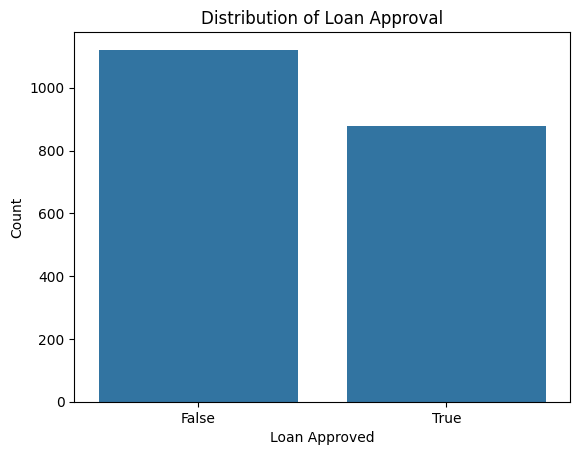

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)
plt.title('Distribution of Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

b) Analyze the relationship between one numerical feature and the target variable.


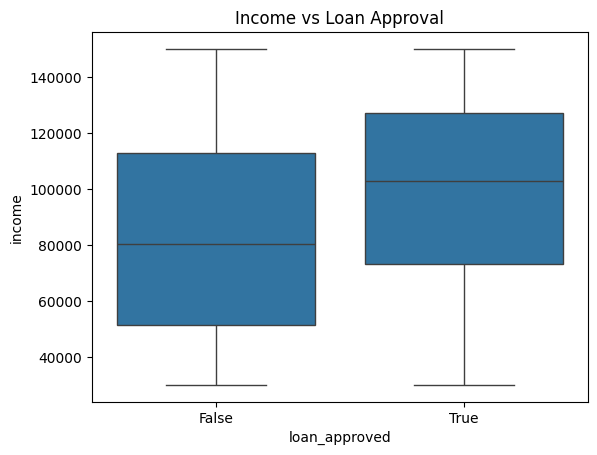

In [89]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title('Income vs Loan Approval')
plt.show()

c) Analyze the relationship between Years of Employment and the target variable.

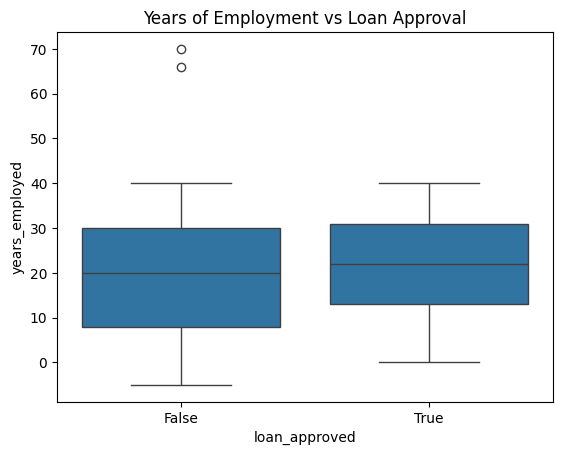

In [90]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title('Years of Employment vs Loan Approval')
plt.show()

Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.


In [91]:
numerical_cols = df.select_dtypes(exclude=['object', 'boolean']).columns
print(numerical_cols)

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points'], dtype='object')


In [92]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


b) Treat outliers using capping techniques

In [93]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

In [94]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
credit_score: 0 outliers
loan_amount: 0 outliers
years_employed: 0 outliers
points: 0 outliers


Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.

In [95]:
df['loan_approved'] = df['loan_approved'].astype(int)

In [96]:
df['loan_approved']

,loan_approved
0,0
1,0
2,0
3,0
4,0
...,...
1995,1
1996,0
1997,1
1998,0


In [97]:
df = df.drop(columns=['name'])
df = df.drop(columns=['city'])

Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y)

In [98]:
X = df[['income',
        'credit_score', 'loan_amount',
        'years_employed', 'points']]
y = df['loan_approved']

b) Split the dataset into training and testing sets.

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 5)
(400, 5)
(1600,)
(400,)


In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Q7. Apply feature scaling to the dataset using StandardScaler.


In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.


In [103]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

b) Predict the output for test data.


In [104]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0
 0 1 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1
 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 1 1
 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 0 0
 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 0 1
 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 0 1
 0 1 1 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0]


Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.


In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[224   0]
 [  0 176]]


b) Interpret the results.


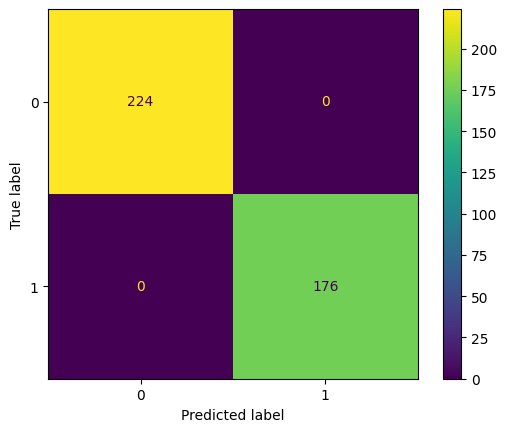

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.


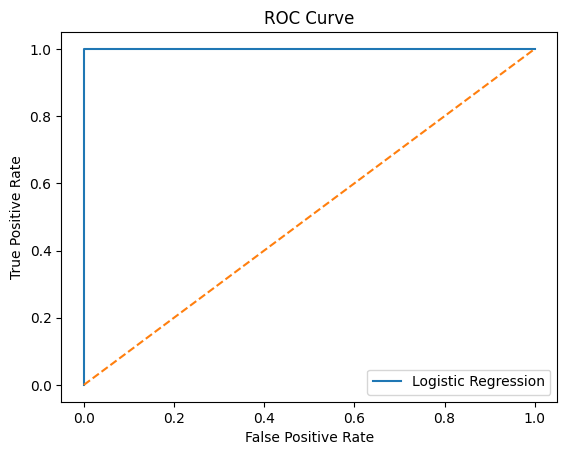

In [111]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

b) Calculate the AUC score.

In [112]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 1.0
